<a target="_blank" href="https://colab.research.google.com/github/Datacompintensive/HS-25-26/blob/master/GoodFeaturesToTrack/stab_v2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>

# Robot Camera Stabilization Pipeline

Research-oriented stabilization pipeline for robot-mounted cameras.

Features:
- Custom directional convolution feature enhancement
- CUDA acceleration for convolution
- GoodFeaturesToTrack on convolution response
- Lucas-Kanade Optical Flow
- RANSAC outlier rejection
- Kalman-based jitter suppression
- Motion diagnostics
- Stabilized video export
- Progress bars with tqdm

## Overview
This pipeline is designed for stabilizing videos captured from robot-mounted or handheld cameras. It combines classical computer vision methods with signal processing to reduce jitter while preserving intentional motion.


In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## Mount Google Drive

This section mounts Google Drive to access input videos and store outputs. It assumes execution in Google Colab.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

VIDEO_PATH = '/content/drive/MyDrive/HS-25-26/img/GoodFeaturesToTrack/chair1.mp4'
OUTPUT_VIDEO = '/content/drive/MyDrive/HS-25-26/img/GoodFeaturesToTrack/stabilized_v2(1)_video.mp4'


Mounted at /content/drive


## Directional Convolution Kernels

Directional convolution kernels are used to enhance motion-relevant edges before feature detection. This improves robustness of keypoint extraction under motion blur and noise.


In [3]:
def make_kernel(N, angle_deg):
    kernel = np.zeros((N, N), dtype=np.float32)
    center = N // 2
    y, x = np.mgrid[-center:center+1, -center:center+1]
    theta = np.deg2rad(angle_deg)
    yr = x*np.sin(theta) + y*np.cos(theta)
    kernel[np.abs(yr) < 0.5] = 1
    kernel[np.abs(yr-1) < 0.5] = -1
    return kernel

N = 9
angles = [0,30,60,90,120,150]

weight = torch.tensor(
    np.stack([make_kernel(N,a) for a in angles])[:,None,:,:],
    dtype=torch.float32,
    device=device
)


## Helper Functions

Helper functions include reusable utilities for frame processing, feature handling, and visualization. They are designed to keep the main pipeline modular.


In [4]:
def convolution_response(gray):

    tensor = torch.tensor(
        gray,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0).unsqueeze(0)

    out = F.conv2d(
        tensor,
        weight,
        padding=N//2
    )

    response = torch.sqrt(
        torch.sum(out**2, dim=1)
    )

    response = response.squeeze().cpu().numpy()

    response = cv2.normalize(
        response,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return response


## Pass 1 - Motion Estimation

This stage estimates inter-frame motion using feature tracking (GoodFeaturesToTrack + optical flow) and robust filtering (RANSAC). It produces raw camera motion trajectories.


In [5]:
cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, prev = cap.read()

prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
prev_response = convolution_response(prev_gray)

motion=[]

for idx in tqdm(range(frame_count-1)):

    features = cv2.goodFeaturesToTrack(
        prev_response,
        maxCorners=1000,
        qualityLevel=0.01,
        minDistance=10,
        blockSize=7
    )

    ret, curr = cap.read()

    if not ret:
        break

    curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)
    curr_response = convolution_response(curr_gray)

    next_pts, status, err = cv2.calcOpticalFlowPyrLK(
        prev_response,
        curr_response,
        features,
        None
    )

    good_old = features[status.flatten()==1]
    good_new = next_pts[status.flatten()==1]

    M, inliers = cv2.estimateAffinePartial2D(
        good_old,
        good_new,
        method=cv2.RANSAC
    )

    if M is not None:

        tx = M[0,2]
        ty = M[1,2]

        theta = np.arctan2(
            M[1,0],
            M[0,0]
        )

        motion.append([
            tx, ty, theta
        ])

    prev_response = curr_response


  0%|          | 0/220 [00:00<?, ?it/s]

## Kalman-Based Motion Smoothing

A Kalman filter is applied to the estimated motion trajectory to suppress high-frequency jitter while preserving smooth camera movement.

Raw motion estimates are noisy due to:

- feature tracking errors  
- lighting changes  
- motion blur  
- occlusions  

Kalman filtering improves stability by:

- modeling motion continuity  
- reducing high-frequency jitter  
- balancing measurement vs prediction uncertainty  



In [6]:
motion = np.array(motion)

tx = motion[:,0]
ty = motion[:,1]
theta = motion[:,2]

kalman = cv2.KalmanFilter(3,3)

kalman.transitionMatrix = np.eye(3, dtype=np.float32)
kalman.measurementMatrix = np.eye(3, dtype=np.float32)

kalman.processNoiseCov = np.eye(3, dtype=np.float32)*1e-4
kalman.measurementNoiseCov = np.eye(3, dtype=np.float32)*1e-2

smooth=[]

for i in range(len(motion)):

    m = np.array([
        [np.float32(tx[i])],
        [np.float32(ty[i])],
        [np.float32(theta[i])]
    ])

    kalman.correct(m)
    pred = kalman.predict()

    smooth.append([
        pred[0,0],
        pred[1,0],
        pred[2,0]
    ])

smooth = np.array(smooth)


## Motion Diagnostics

Diagnostics visualize motion trajectories, residual errors, and stabilization effectiveness to evaluate system performance.


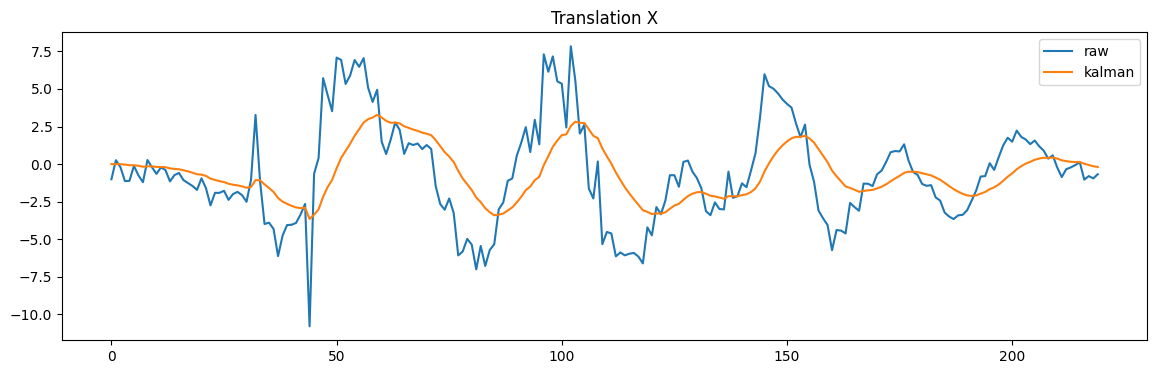

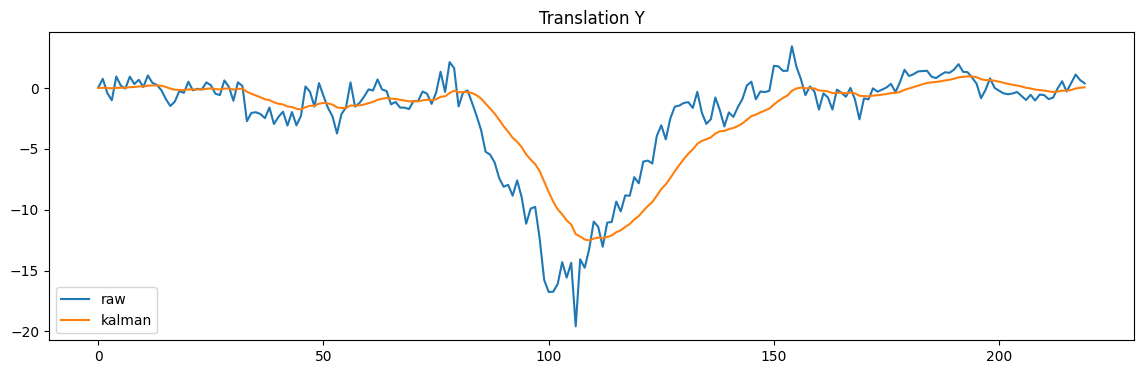

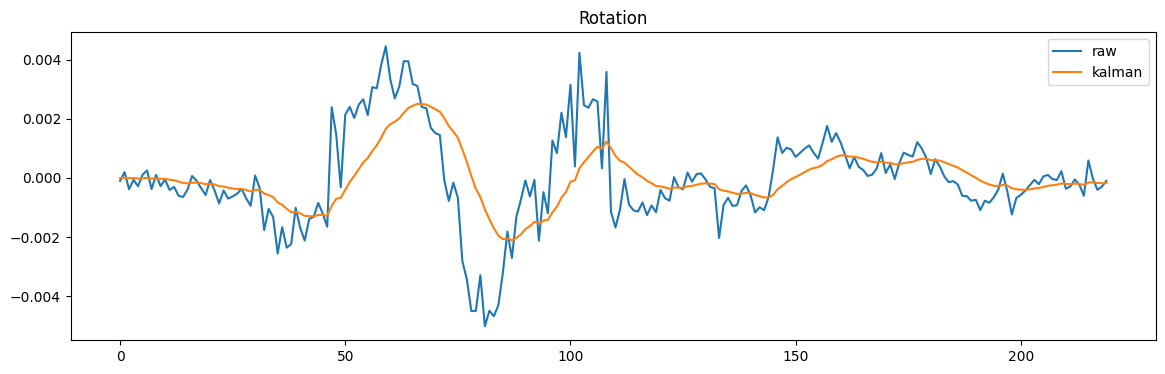

In [7]:
plt.figure(figsize=(14,4))
plt.plot(tx,label='raw')
plt.plot(smooth[:,0],label='kalman')
plt.title('Translation X')
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(ty,label='raw')
plt.plot(smooth[:,1],label='kalman')
plt.title('Translation Y')
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(theta,label='raw')
plt.plot(smooth[:,2],label='kalman')
plt.title('Rotation')
plt.legend()
plt.show()


## Pass 2 - Video Stabilization

This stage applies the computed smoothed motion model to warp frames and generate the stabilized output video.


In [8]:
cap = cv2.VideoCapture(VIDEO_PATH)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    fourcc,
    fps,
    (width,height)
)

ret, frame = cap.read()

writer.write(frame)

for i in tqdm(range(len(smooth))):

    ret, frame = cap.read()

    if not ret:
        break

    dtx = smooth[i,0] - tx[i]
    dty = smooth[i,1] - ty[i]

    dtheta = smooth[i,2] - theta[i]

    cos_t = np.cos(dtheta)
    sin_t = np.sin(dtheta)

    M = np.array([
        [cos_t,-sin_t,dtx],
        [sin_t, cos_t,dty]
    ], dtype=np.float32)

    stabilized = cv2.warpAffine(
        frame,
        M,
        (width,height),
        borderMode=cv2.BORDER_REFLECT
    )

    writer.write(stabilized)

writer.release()

print('Saved:', OUTPUT_VIDEO)


  0%|          | 0/220 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/HS-25-26/img/GoodFeaturesToTrack/stabilized_v2(1)_video.mp4


## Export Motion Statistics

Motion statistics (translation, rotation, drift) are exported for further analysis and debugging of the stabilization pipeline.


In [9]:
df = pd.DataFrame({
    'tx_raw':tx,
    'ty_raw':ty,
    'rot_raw':theta,
    'tx_smooth':smooth[:,0],
    'ty_smooth':smooth[:,1],
    'rot_smooth':smooth[:,2]
})

df.to_csv('motion_statistics.csv',index=False)
df.head()


,tx_raw,ty_raw,rot_raw,tx_smooth,ty_smooth,rot_smooth
0,-1.009651,0.039507,-0.000103,0.000000,0.000000,0.000000
1,0.259451,0.752620,0.000195,0.002569,0.007452,0.000002
2,-0.198767,-0.416123,-0.000379,-0.001360,-0.000813,-0.000006
3,-1.132180,-1.012360,-0.000066,-0.033777,-0.029811,-0.000007
4,-1.114419,0.934221,-0.000280,-0.074006,0.006077,-0.000017
